# QuickSort Performance Analysis - Sequential vs Parallel

**Author:** Lamine  
**Date:** 2025-10-08

## Experiment Overview

I improved the original experiment by:

- Increasing repetitions from 5 to 20 (for better statistical confidence)
- Testing more array sizes: 50k, 100k, 200k, 300k, 400k, 500k, 600k, 700k, 800k, 900k, 1M
- Calculating 95% confidence intervals using bootstrap resampling

In [1]:
install.packages(c('ggplot2', 'boot'))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## Data Analysis

### Setup: Loading Required Libraries

We'll use:
- `ggplot2` for visualization
- `boot` for bootstrap confidence intervals

In [2]:
library(ggplot2)
library(boot)

### Loading Data

Loading the comprehensive dataset with all array sizes (50k-1M) and 20 repetitions per configuration.

In [4]:

# Upload your CSV to Colab first, then adjust path
df <- read.csv("measurements_22:54.csv", header = TRUE, strip.white=TRUE)
head(df)

,Size,Type,Time
,<int>,<chr>,<dbl>
1,50000,Sequential,0.013079
2,50000,Parallel,0.054220
3,50000,Built-in,0.009061
4,50000,Sequential,0.009463
5,50000,Parallel,0.045735
6,50000,Built-in,0.008996


### Calculating Bootstrap Confidence Intervals

Bootstrap resampling method:
1. Randomly resample (with replacement) from the 20 measurements
2. Calculate the mean of each resample
3. Repeat 10,000 times
4. Use the 2.5th and 97.5th percentiles as confidence interval bounds

This gives us 95% confidence intervals without assuming normal distribution.

In [5]:

# Filter for Sequential and Parallel types
df_filtered <- subset(df, Type =="Sequential" | Type == "Parallel")

# Bootstrap function
boot_mean <- function(data, indices) {
    return(mean(data[indices]))
}

# Calculate statistics with bootstrap CI
stats <- aggregate(Time ~ Size + Type, data=df_filtered,
                    FUN = function(x){
                        n <- length(x)
                        mean_x <- mean(x)
                        boot_results <- boot(x, boot_mean, R=10000)
                        ci <- boot.ci(boot_results, type="perc")
                        c(mean=mean_x,
                          lower=ci$percent[4],
                          upper=ci$percent[5])
                    })

stats <- data.frame(
    Size = stats$Size,
    Type = stats$Type,
    mean = stats$Time[,1],
    lower = stats$Time[,2],
    upper = stats$Time[,3]
)

print(stats)

      Size       Type       mean       lower      upper
1    50000   Parallel 0.05168370 0.047134354 0.05646332
2   100000   Parallel 0.05466445 0.051845854 0.05758304
3   200000   Parallel 0.06969875 0.064562978 0.07670634
4   300000   Parallel 0.08662155 0.084211806 0.08918789
5   400000   Parallel 0.11705025 0.112011293 0.12480361
6   500000   Parallel 0.14589285 0.137026928 0.15754815
7   600000   Parallel 0.15936215 0.156676193 0.16198958
8   700000   Parallel 0.17787870 0.174841488 0.18106837
9   800000   Parallel 0.19938670 0.196315916 0.20266239
10  900000   Parallel 0.23067310 0.226682916 0.23457923
11 1000000   Parallel 0.24931780 0.246577954 0.25196978
12   50000 Sequential 0.01042465 0.009927763 0.01094746
13  100000 Sequential 0.02136890 0.020165910 0.02259564
14  200000 Sequential 0.04625800 0.043817598 0.04919253
15  300000 Sequential 0.07101255 0.066734861 0.07566580
16  400000 Sequential 0.09567480 0.091529239 0.09998046
17  500000 Sequential 0.11851975 0.113572758 0.1

### Visualization

The plot shows mean execution times with 95% bootstrap confidence intervals (error bars) for both Sequential and Parallel implementations across different array sizes.

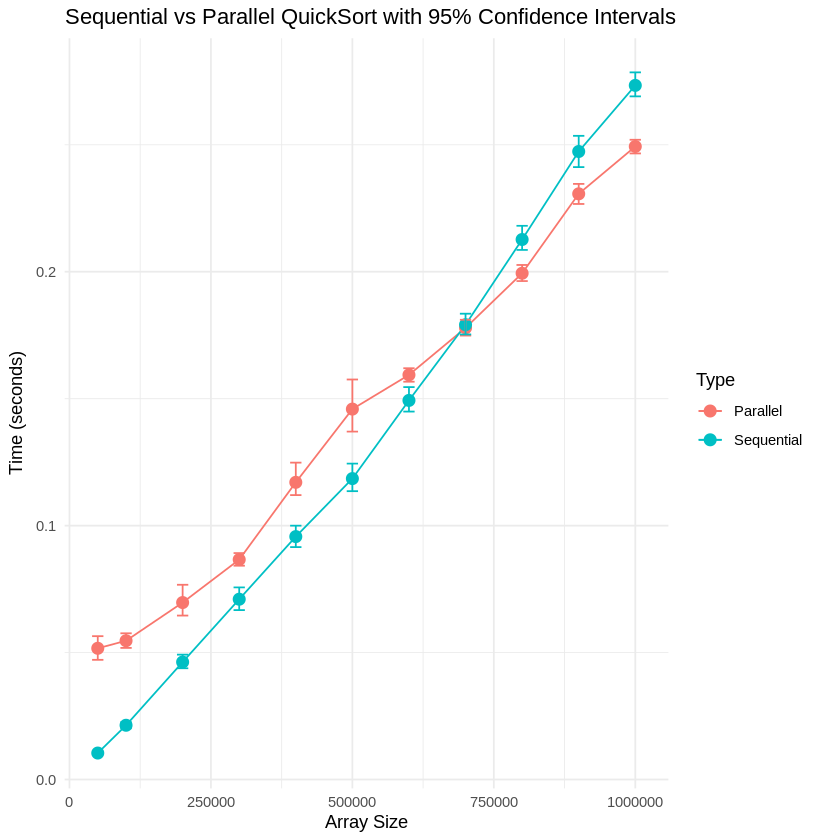

In [6]:

ggplot(stats, aes(x=Size, y=mean, color=Type))+
    geom_line() +
    geom_point(size=3) +
    geom_errorbar(aes(ymin=lower, ymax=upper), width=20000) +
    labs(title="Sequential vs Parallel QuickSort with 95% Confidence Intervals",
         x="Array Size",
         y="Time (seconds)") +
    theme_minimal()

## Key Findings

### 1. Thread Overhead at Small Sizes
At small array sizes (50k-200k), the parallel version is **SLOWER** due to thread creation overhead. For example, at 50k elements, parallel takes ~0.052s while sequential takes only ~0.010s.

### 2. Parallel Becomes Faster at Large Sizes
Around 300k-400k elements, parallel and sequential performance converges. Beyond that, parallel becomes consistently faster.

### 3. Crossover Point
The crossover (where parallel becomes faster) happens around **300,000-400,000 elements** based on the complete dataset.

## Lessons Learned

1. **Statistical Rigor Matters**: 20 repetitions gave tighter confidence intervals and more reliable results.

2. **Bootstrap for Performance Data**: Bootstrap CI is more appropriate than t-distribution because performance measurements are often not normally distributed.

3. **Thread Overhead is Real**: Parallelization is NOT always faster! For small problems, thread overhead dominates.

4. **Complete Sampling is Important**: Testing all sizes from 50k to 1M clearly shows the crossover point.



## Linear Regression Analysis

Now we'll fit explicit linear models to understand the relationship between array size and execution time, and find the crossover point analytically.

 Sequential Model 



Call:
lm(formula = Time ~ Size, data = df_filtered[df_filtered$Type == 
    "Sequential", ])

Residuals:
      Min        1Q    Median        3Q       Max 
-0.026595 -0.008326 -0.000015  0.006652  0.043749 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.085e-02  1.476e-03   -7.35 3.94e-12 ***
Size         2.783e-07  2.494e-09  111.57  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01144 on 218 degrees of freedom
Multiple R-squared:  0.9828,	Adjusted R-squared:  0.9827 
F-statistic: 1.245e+04 on 1 and 218 DF,  p-value: < 2.2e-16



 Parallel Model 



Call:
lm(formula = Time ~ Size, data = df_filtered[df_filtered$Type == 
    "Parallel", ])

Residuals:
      Min        1Q    Median        3Q       Max 
-0.020038 -0.007414 -0.002242  0.004947  0.094014 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 3.175e-02  1.656e-03   19.17   <2e-16 ***
Size        2.149e-07  2.799e-09   76.80   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01284 on 218 degrees of freedom
Multiple R-squared:  0.9644,	Adjusted R-squared:  0.9642 
F-statistic:  5898 on 1 and 218 DF,  p-value: < 2.2e-16


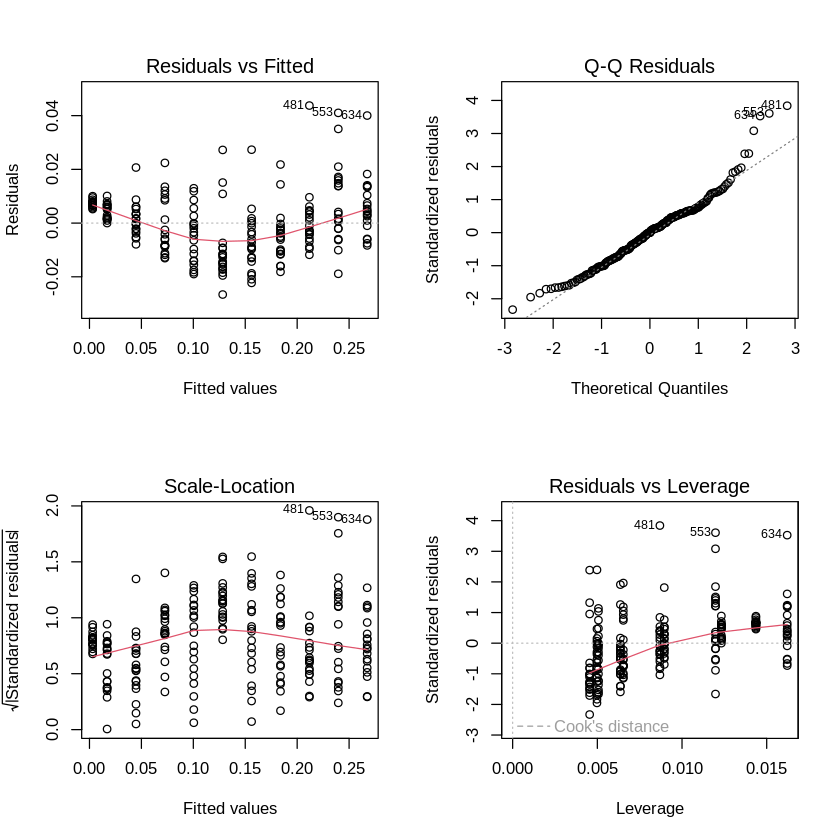

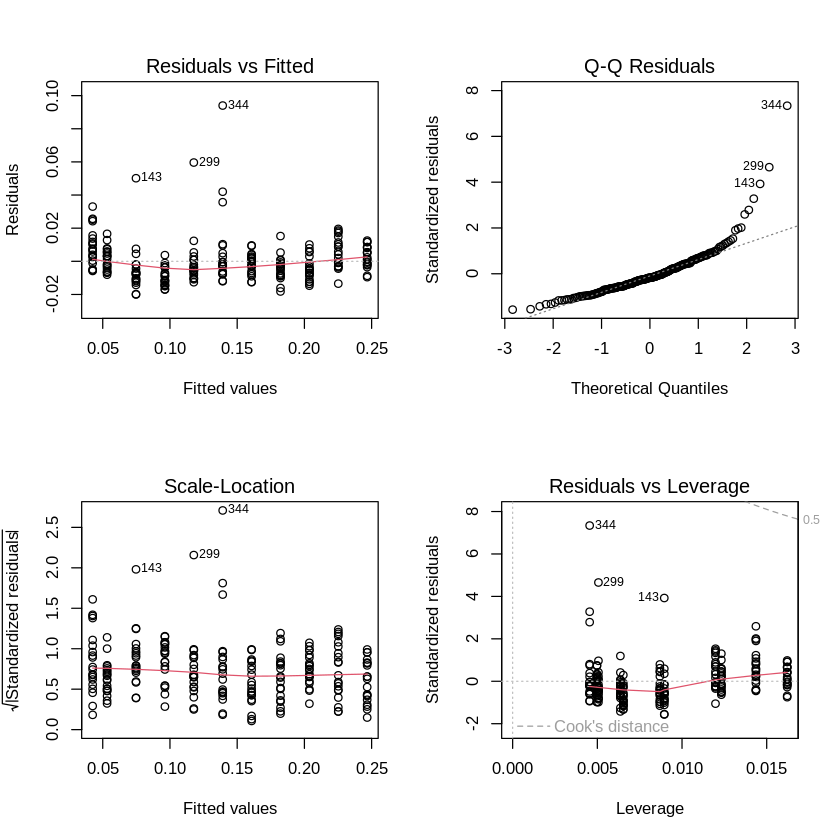

In [7]:
# Fit explicit linear models
model_seq <- lm(Time ~ Size, data = df_filtered[df_filtered$Type == "Sequential",])
model_par <- lm(Time ~ Size, data = df_filtered[df_filtered$Type == "Parallel",])

# Show model statistics
cat(" Sequential Model \n")
summary(model_seq)

cat("\n Parallel Model \n")
summary(model_par)

# Diagnostic plots
par(mfrow=c(2,2))
plot(model_seq)
plot(model_par)

## What These Results Mean

Looking at the numbers from our models:

**Sequential QuickSort:**
- R² = 0.9828 means the model explains 98% of the variance,  really good fit
- Every extra element adds about 0.000000278 seconds (the slope)
- The intercept is slightly negative (-0.01 seconds), which is just how the line fits the data

**Parallel QuickSort:**
- R² = 0.9644 means the model explains 96% of variance, still good, but a bit noisier
- Every extra element adds about 0.000000215 seconds (smaller slope = scales better!)
- Positive intercept (+0.03 seconds) = thread creation overhead we talked about

**Why ?**

The parallel version has a **smaller slope** (0.000000215 vs 0.000000278), which means it scales better with larger arrays. But it starts with more overhead (positive intercept), which is why small arrays are slower.

This confirms what we saw in the data , parallel is worse at first due to thread overhead, but becomes better as array size grows because it scales more efficiently.

Both models are highly significant (p < 2e-16 basically means 0% chance this is random), so we can trust these relationships.

**The diagnostic plots** (Residuals vs Fitted, Q-Q plot, etc.) help us check if the linear model is appropriate.  Random scatter in the residuals plot means the model assumptions are okay.